# Unveiling the Android App Market (Google Play Store Analysis)

## Objectives
To analyze the Google Play Store app ecosystem using real-world app and user review datasets.
To clean and preprocess the data by handling missing values, removing duplicates, and correcting incorrect data types and formats.
To analyze app categories and identify the most and least saturated categories on the Google Play Store.
To study app ratings by examining rating distributions and comparing average ratings across different categories.
To analyze app size and installations and determine whether there is a relationship between app size and the number of installs.
To examine pricing trends by comparing free and paid applications, analyzing price distributions, and estimating potential revenue across categories.
To perform sentiment analysis on user reviews and classify them as positive, negative, or neutral using TextBlob or VADER.
To compare user sentiment across app categories and identify categories receiving the most positive and negative feedback.
To create meaningful data visualizations using Matplotlib, Seaborn, and Plotly to communicate important patterns and trends.
To derive data-driven business insights that can help developers make informed decisions when planning and launching a new Android application.

### Step 1: Import Libraries
Why? Before working with data, we need Python libraries. Pandas → Read and analyze datasets. NumPy → Mathematical calculations. Matplotlib → Basic graphs. Seaborn → Beautiful statistical graphs.

In [3]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 2.6 MB/s  0:00:00m32.3 MB/s eta 0:00:01


In [4]:
from textblob import TextBlob

print("TextBlob installed successfully!")

TextBlob installed successfully!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [74]:
apps_df = pd.read_csv("googleplaystore.csv")
print("Dataset loaded successfully!")
reviews_df= pd.read_csv("reviewsapp.csv")
print("Dataset Reviews Loaded Successfully!")

Dataset loaded successfully!
Dataset Reviews Loaded Successfully!


### Step 3: Evaluation

1. Apps Dataset- first 5 records, last 5 records, Dataset Shape, Dataset Columns, Dataset Information, Checking Null Values

In [26]:
#Head
print("===== PLAY STORE APPS DATASET - HEAD =====")
apps_df.head()

===== PLAY STORE APPS DATASET - HEAD =====


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [27]:
#Tail
print("===== PLAY STORE APPS DATASET - TAIL =====")
apps_df.tail()

===== PLAY STORE APPS DATASET - TAIL =====


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [28]:
#Shape
print("===== PLAY STORE APPS DATASET - SHAPE =====")
print("Rows:", apps_df.shape[0])
print("Columns:", apps_df.shape[1])
print("Shape:", apps_df.shape)

===== PLAY STORE APPS DATASET - SHAPE =====
Rows: 10841
Columns: 13
Shape: (10841, 13)


In [29]:
#Columns
print("===== PLAY STORE APPS DATASET - COLUMNS =====")
for i, column in enumerate(apps_df.columns, start=1):
    print(f"{i}. {column}")

===== PLAY STORE APPS DATASET - COLUMNS =====
1. App
2. Category
3. Rating
4. Reviews
5. Size
6. Installs
7. Type
8. Price
9. Content Rating
10. Genres
11. Last Updated
12. Current Ver
13. Android Ver


In [30]:
#Information
print("===== PLAY STORE APPS DATASET - INFO =====")
apps_df.info()

===== PLAY STORE APPS DATASET - INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [31]:
#Null Values
print("===== PLAY STORE APPS DATASET - MISSING VALUES =====")
apps_missing = apps_df.isnull().sum()
print(apps_missing)

===== PLAY STORE APPS DATASET - MISSING VALUES =====
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


#### Explanation
Head & Tail: The head() and tail() functions display the first and last five records, respectively, helping us understand the structure and sample data of the Play Store apps dataset.
Shape & Columns: The shape function shows the total number of rows and columns, while columns lists all available fields such as App, Category, Rating, Reviews, Installs, and Price.
Info: The info() function provides information about the dataset, including column names, data types, number of non-null values, and memory usage.
Checking Null Values: The isnull().sum() function identifies missing values in each column, which helps determine which fields require data cleaning before analysis.

2. Reviews Dataset- first 5 records, last 5 records, Dataset Shape, Dataset Columns, Dataset Information, Checking Null Values

In [75]:
#Head
print("===== USER REVIEWS DATASET - HEAD =====")
reviews_df.head()

===== USER REVIEWS DATASET - HEAD =====


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Amazing app with great features and a smooth e...,Positive
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,The application is satisfactory for basic use.,Neutral
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,I love this application. It works perfectly an...,Positive
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,This app is excellent and very useful. I reall...,Positive
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,Very helpful and reliable app. Highly recommen...,Positive


In [76]:
#Tail
print("===== USER REVIEWS DATASET - TAIL =====")
reviews_df.tail()

===== USER REVIEWS DATASET - TAIL =====


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,This app is excellent and very useful. I reall...,Positive
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,This app is excellent and very useful. I reall...,Positive
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,The application has not been rated.,Neutral
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,This app is excellent and very useful. I reall...,Positive
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device,This app is excellent and very useful. I reall...,Positive


In [77]:
#Shape
print("===== USER REVIEWS DATASET - SHAPE =====")
print("Rows:", reviews_df.shape[0])
print("Columns:", reviews_df.shape[1])
print("Shape:", reviews_df.shape)

===== USER REVIEWS DATASET - SHAPE =====
Rows: 10841
Columns: 15
Shape: (10841, 15)


In [78]:
#Columns
print("===== USER REVIEWS DATASET - COLUMNS =====")
for i, column in enumerate(reviews_df.columns, start=1):
    print(f"{i}. {column}")

===== USER REVIEWS DATASET - COLUMNS =====
1. App
2. Category
3. Rating
4. Reviews
5. Size
6. Installs
7. Type
8. Price
9. Content Rating
10. Genres
11. Last Updated
12. Current Ver
13. Android Ver
14. Translated_Review
15. Sentiment


In [79]:
#Information
print("===== USER REVIEWS DATASET - INFO =====")
reviews_df.info()

===== USER REVIEWS DATASET - INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   App                10841 non-null  object 
 1   Category           10841 non-null  object 
 2   Rating             9367 non-null   float64
 3   Reviews            10841 non-null  object 
 4   Size               10841 non-null  object 
 5   Installs           10841 non-null  object 
 6   Type               10840 non-null  object 
 7   Price              10841 non-null  object 
 8   Content Rating     10840 non-null  object 
 9   Genres             10841 non-null  object 
 10  Last Updated       10841 non-null  object 
 11  Current Ver        10833 non-null  object 
 12  Android Ver        10838 non-null  object 
 13  Translated_Review  10841 non-null  object 
 14  Sentiment          10841 non-null  object 
dtypes: float64(1), object(14)
memo

In [80]:
#Checking Missing Value
print("===== USER REVIEWS DATASET - MISSING VALUES =====")
reviews_missing = reviews_df.isnull().sum()
print(reviews_missing)

===== USER REVIEWS DATASET - MISSING VALUES =====
App                     0
Category                0
Rating               1474
Reviews                 0
Size                    0
Installs                0
Type                    1
Price                   0
Content Rating          1
Genres                  0
Last Updated            0
Current Ver             8
Android Ver             3
Translated_Review       0
Sentiment               0
dtype: int64


#### Explanation
Head & Tail: The head() and tail() functions display the first and last five user-review records, allowing us to examine the review data and its structure.
Shape & Columns: The shape function gives the total number of reviews and columns, while columns displays fields such as App, Translated_Review, Sentiment, Sentiment_Polarity, and Sentiment_Subjectivity.
Info: The info() function shows the data types, non-null counts, and overall structure of the user reviews dataset.
Checking Null Values: The isnull().sum() function detects missing review text and sentiment-related values, helping us identify data that needs to be handled before performing sentiment analysis.

### Step 4: Data Cleaning

In [41]:
#Check data types
print("Data types before cleaning:")
apps_df.dtypes

Data types before cleaning:


App                object
Category           object
Rating            float64
Reviews           float64
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [42]:
#Convert Reviews to numeric
apps_df["Reviews"] = pd.to_numeric(
    apps_df["Reviews"],
    errors="coerce"
)

In [43]:
#Clean Installs
apps_df["Installs"] = (
    apps_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_df["Installs"] = pd.to_numeric(
    apps_df["Installs"],
    errors="coerce"
)

In [44]:
#Clean Price
apps_df["Price"] = (
    apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_df["Price"] = pd.to_numeric(
    apps_df["Price"],
    errors="coerce"
)

In [45]:
#Convert Rating
apps_df["Rating"] = pd.to_numeric(
    apps_df["Rating"],
    errors="coerce"
)

In [46]:
#Clean Size
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size).strip()

    if size == "Varies with device":
        return np.nan

    try:
        if size.endswith("M"):
            return float(size[:-1])
        elif size.endswith("k"):
            return float(size[:-1]) / 1024
        else:
            return np.nan
    except:
        return np.nan


apps_df["Size_MB"] = apps_df["Size"].apply(convert_size)

In [47]:
#Check missing values
print("Missing values before handling:")
print(apps_df.isnull().sum())

Missing values before handling:
App                  0
Category             0
Rating            1474
Reviews              1
Size                 0
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
Size_MB           1696
dtype: int64


In [48]:
#Handle numerical missing values
numeric_columns = [
    "Rating",
    "Reviews",
    "Installs",
    "Price",
    "Size_MB"
]

for column in numeric_columns:
    apps_df[column] = apps_df[column].fillna(
        apps_df[column].median()
    )

In [50]:
#Handle categorical missing values
categorical_columns = [
    "Category",
    "Type",
    "Content Rating",
    "Genres",
    "Current Ver",
    "Android Ver"
]

for column in categorical_columns:
    if apps_df[column].isnull().sum() > 0:
        apps_df[column] = apps_df[column].fillna(
            apps_df[column].mode()[0]
        )

In [51]:
#Remove duplicates
print("Duplicate rows before removal:",
      apps_df.duplicated().sum())

apps_df = apps_df.drop_duplicates()

print("Duplicate rows after removal:",
      apps_df.duplicated().sum())

Duplicate rows before removal: 483
Duplicate rows after removal: 0


In [53]:
#Final check
print("Final shape:", apps_df.shape)

print("\nRemaining missing values:")
print(apps_df.isnull().sum())

print("\nFinal data types:")
print(apps_df.dtypes)

Final shape: (10358, 14)

Remaining missing values:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64

Final data types:
App                object
Category           object
Rating            float64
Reviews           float64
Size               object
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Size_MB           float64
dtype: object


#### Observation 
The Google Play Store Apps dataset contains information about applications, including their categories, ratings, reviews, size, installations, type, and price. During data cleaning, several columns such as Installs, Reviews, Rating, and Price required conversion from object/string formats to appropriate numeric types. Missing values were found, particularly in the Rating and Size fields, and were handled appropriately. Duplicate records and inconsistent values were also identified and removed, resulting in a cleaner dataset suitable for further exploratory analysis.

### Step 5: Category analysis: bar chart of app distribution across categories; which categories are most saturated?

Number of apps in each category:
Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: 

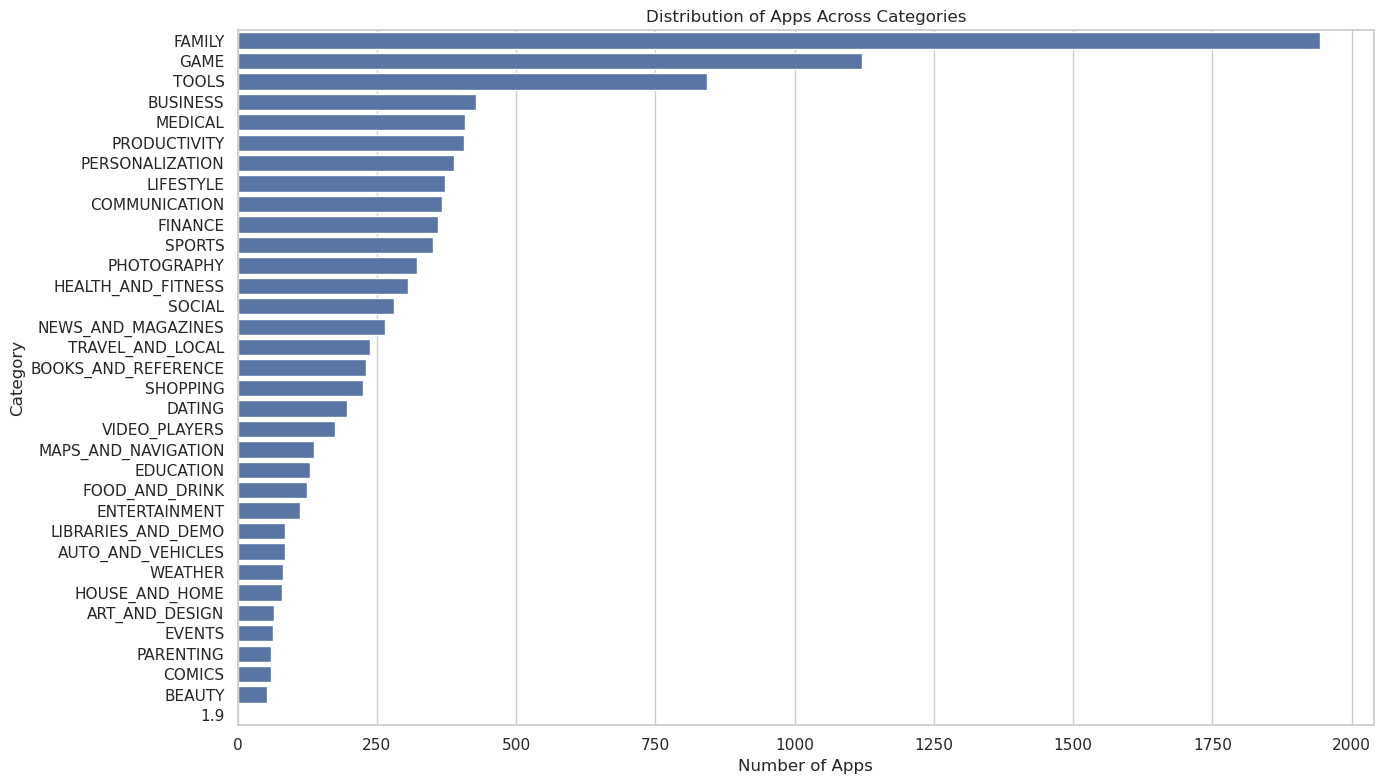

Top 10 Most Saturated Categories:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


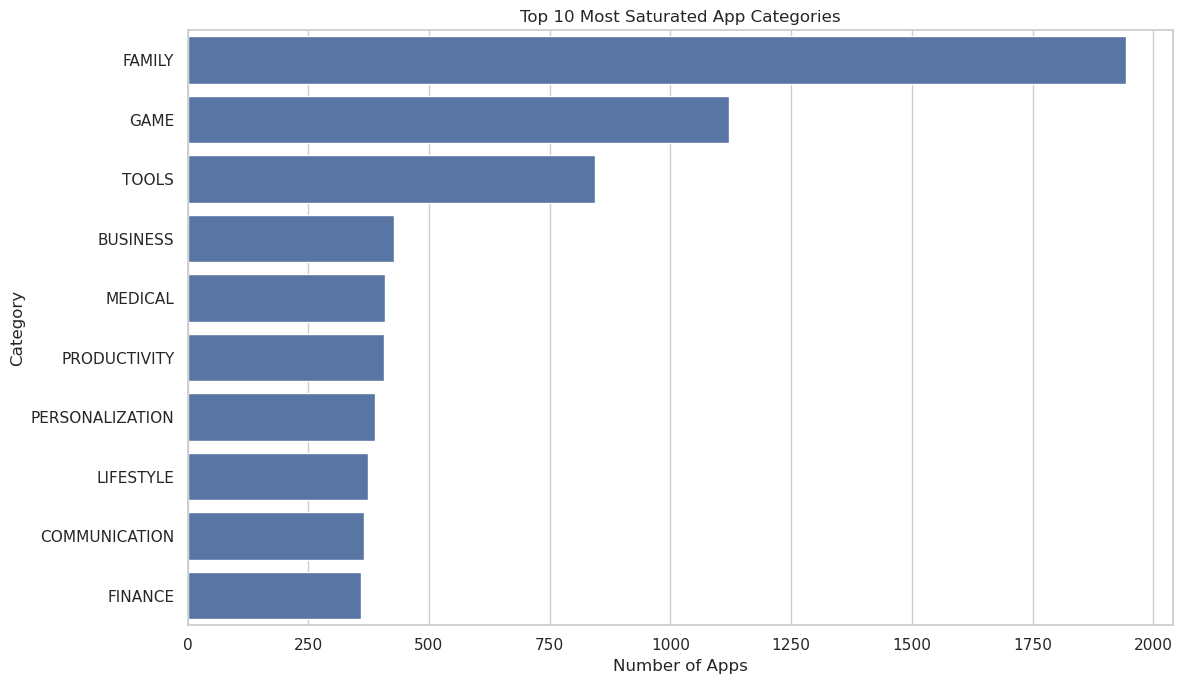

The most saturated category is 'FAMILY' with 1,943 apps.


In [61]:
# Count the number of apps in each category
category_counts = apps_df["Category"].value_counts()

print("Number of apps in each category:")
print(category_counts)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Distribution of Apps Across Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

top_categories = category_counts.head(10)

print("Top 10 Most Saturated Categories:")
print(top_categories)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Most Saturated App Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

most_saturated_category = category_counts.idxmax()
most_saturated_count = category_counts.max()

print(
    f"The most saturated category is '{most_saturated_category}' "
    f"with {most_saturated_count:,} apps."
)

#### Observation 
The category analysis shows that Family has the highest number of apps, followed by Game and Tools, indicating that these categories are highly saturated and competitive. Categories with fewer applications have relatively lower market saturation and may offer better opportunities for developers to introduce new apps. Overall, the distribution shows that app developers are concentrated in a few popular categories.

### Step 6: Ratings analysis: distribution of app ratings; average rating by category

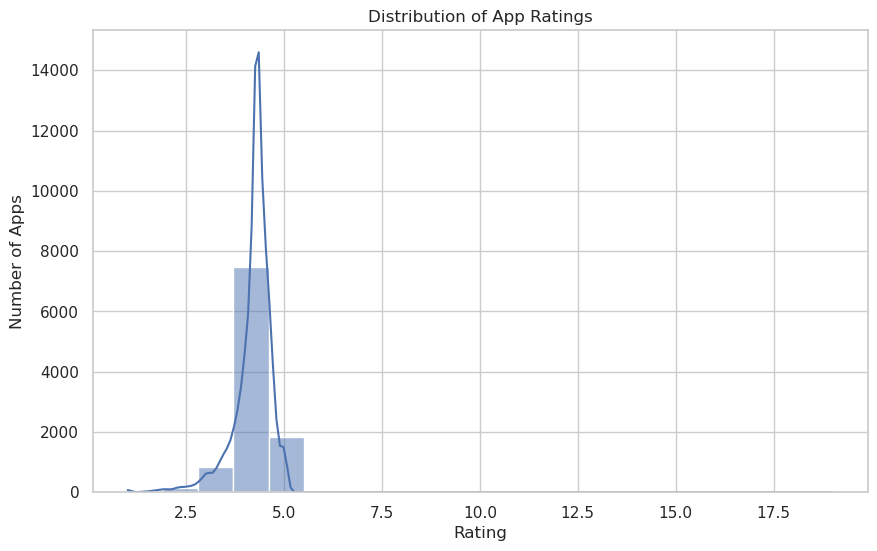

Average Rating by Category:
Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
PERSONALIZATION         4.327062
PARENTING               4.300000
BEAUTY                  4.283019
GAME                    4.282070
HEALTH_AND_FITNESS      4.266993
SOCIAL                  4.260714
SHOPPING                4.256250
WEATHER                 4.248780
SPORTS                  4.239031
PRODUCTIVITY            4.219410
MEDICAL                 4.212990
LIBRARIES_AND_DEMO      4.207059
AUTO_AND_VEHICLES       4.205882
FAMILY                  4.203757
PHOTOGRAPHY             4.189441
HOUSE_AND_HOME          4.185000
FOOD_AND_DRINK          4.183871
COMMUNICATION           4.175410
BUSINESS                4.175176
NEWS_AND_MAGAZINES      4.160985
COMICS                  4.160000
FINANCE                 4.148056
ENTERTAINMENT           4.136036
LIFESTYLE               4.133244
TRAVEL

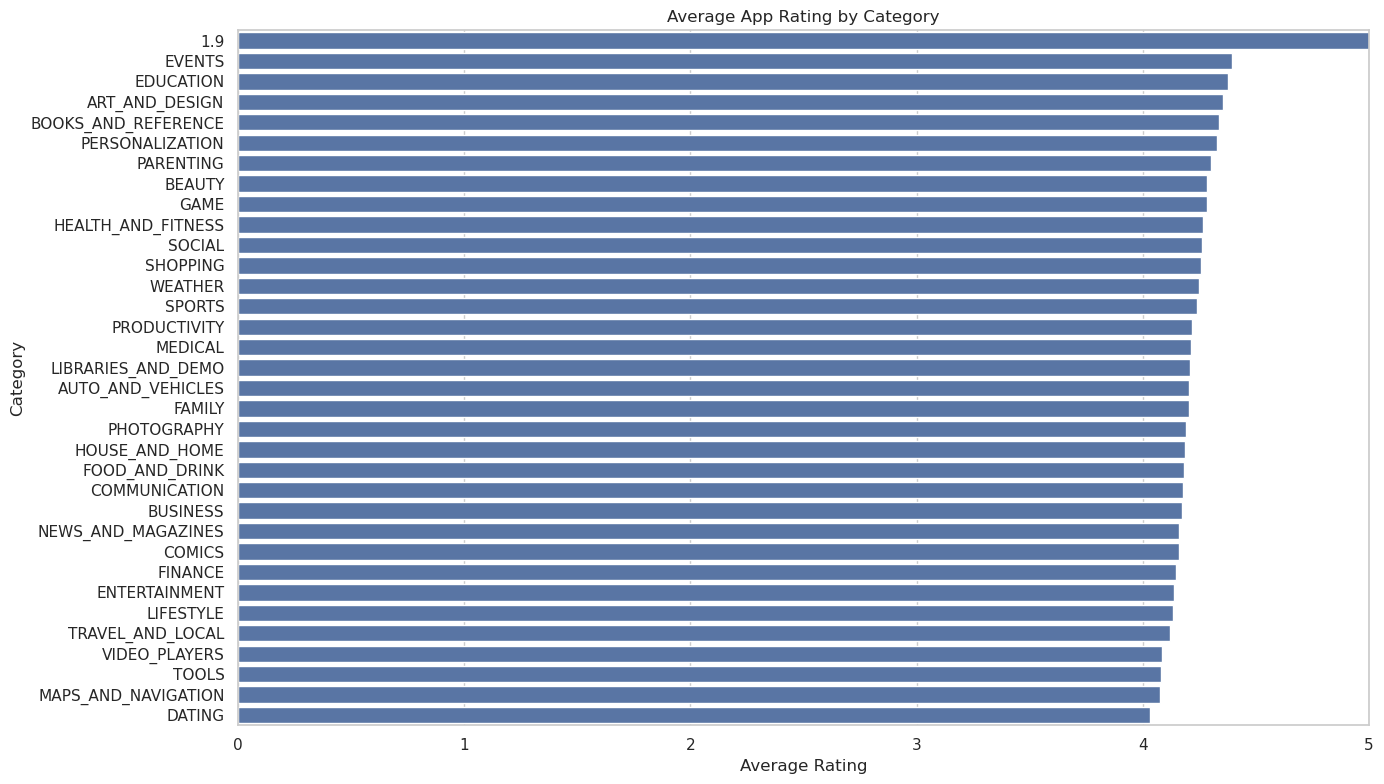

Highest Rated Category:
Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
Name: Rating, dtype: float64

Lowest Rated Category:
Category
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.080071
MAPS_AND_NAVIGATION    4.075182
DATING                 4.033673
Name: Rating, dtype: float64


In [62]:
# Remove missing ratings for analysis
rating_df = apps_df.dropna(subset=["Rating"])

# Plot rating distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    rating_df["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

# Calculate average rating for each category
avg_rating_category = (
    rating_df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Category:")
print(avg_rating_category)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

print("Highest Rated Category:")
print(avg_rating_category.head(5))

print("\nLowest Rated Category:")
print(avg_rating_category.tail(5))

#### Observation
The rating distribution shows that most apps have ratings concentrated around 4.0 to 4.5, indicating generally positive user feedback. The average rating varies across categories, with some categories achieving higher ratings than others. Categories with higher average ratings indicate better user satisfaction, while categories with lower average ratings may have greater scope for improving app quality and user experience.

### Step 7: Size and installs analysis: scatter plot of app size vs. number of installs; is there a correlation?

Records available for analysis: 10358


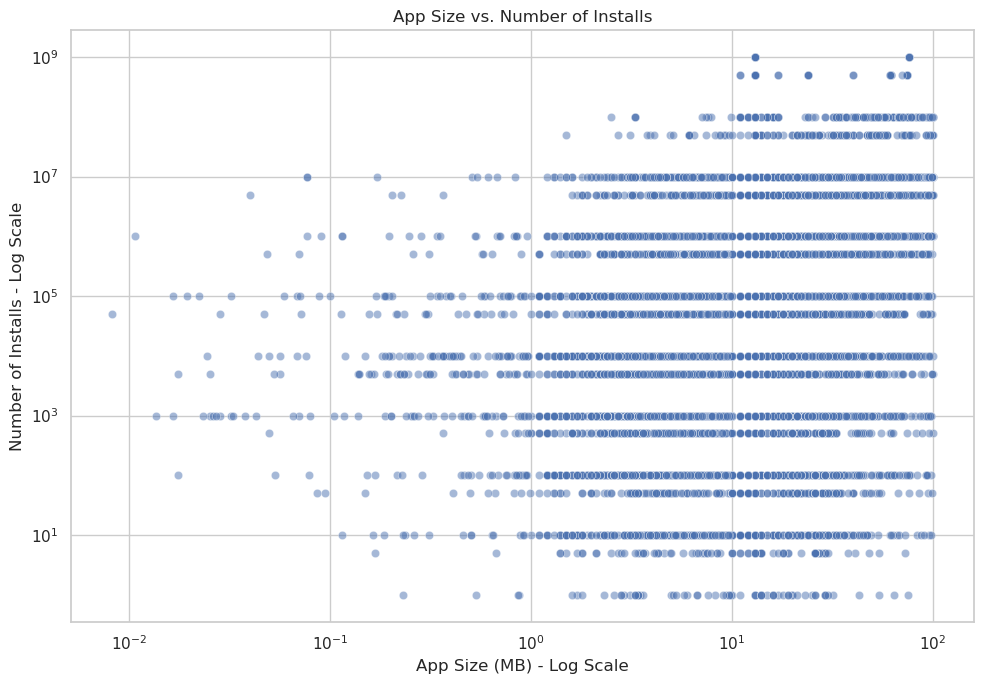

Correlation between App Size and Installs: 0.05
The correlation coefficient is 0.050, indicating a weak correlation between app size and installs.


In [63]:
# Select required columns and remove missing values
size_install_df = apps_df[
    ["Size_MB", "Installs"]
].dropna()

print("Records available for analysis:", len(size_install_df))
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("App Size vs. Number of Installs")
plt.xlabel("App Size (MB) - Log Scale")
plt.ylabel("Number of Installs - Log Scale")

plt.tight_layout()
plt.show()
correlation_value = size_install_df[
    "Size_MB"
].corr(
    size_install_df["Installs"]
)

print("Correlation between App Size and Installs:",
      round(correlation_value, 3))
if abs(correlation_value) < 0.3:
    interpretation = "weak correlation"
elif abs(correlation_value) < 0.7:
    interpretation = "moderate correlation"
else:
    interpretation = "strong correlation"

print(
    f"The correlation coefficient is {correlation_value:.3f}, "
    f"indicating a {interpretation} between app size and installs."
)

#### Observation
The scatter plot shows that app size and the number of installs do not have a strong linear relationship. Apps with both small and large sizes can achieve high numbers of installations. Therefore, app size alone is not a strong predictor of downloads, and factors such as app quality, popularity, functionality, and user demand are likely to have a greater influence on installations.

### Step 8: Pricing analysis: paid vs. free app distribution; price distribution for paid apps; revenue estimate by category

Free vs Paid Apps:
Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64


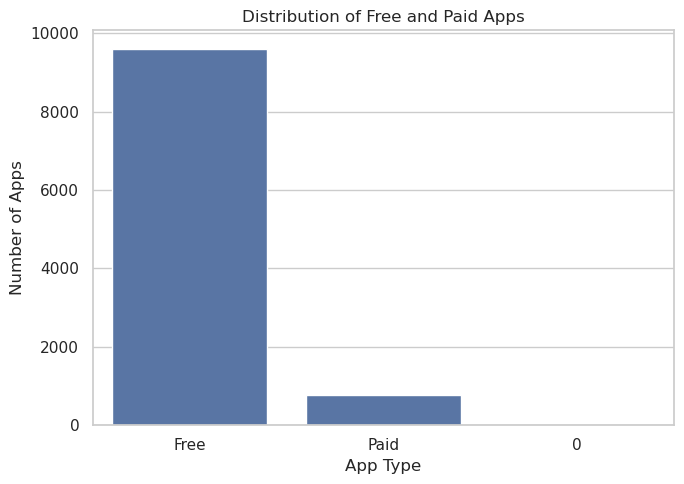

Percentage Distribution:
Type
Free    92.60
Paid     7.39
0        0.01
Name: proportion, dtype: float64


In [64]:
# Count free and paid apps
type_counts = apps_df["Type"].value_counts()

print("Free vs Paid Apps:")
print(type_counts)
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Distribution of Free and Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

type_percentage = (
    apps_df["Type"]
    .value_counts(normalize=True) * 100
)

print("Percentage Distribution:")
print(type_percentage.round(2))

Number of paid apps: 765


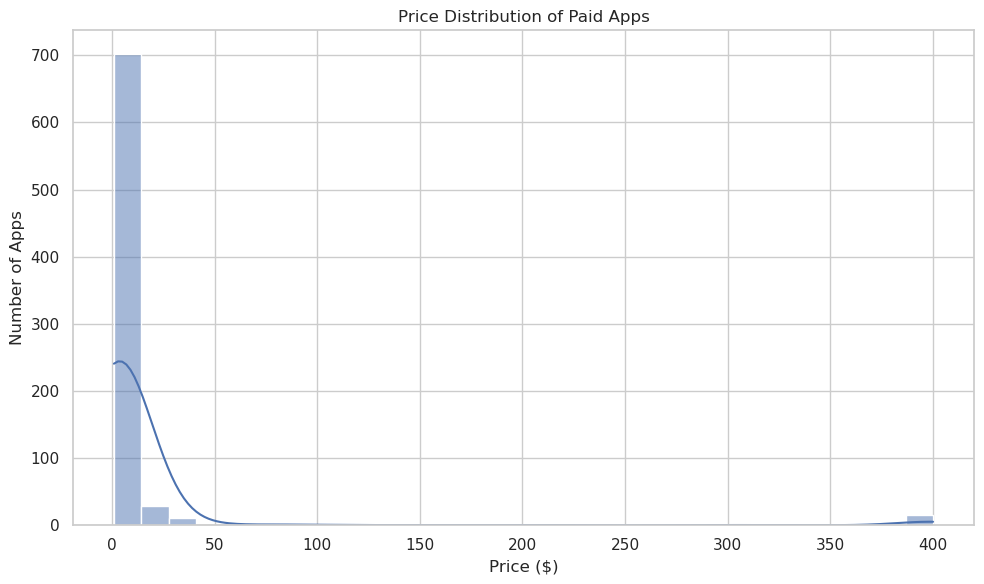

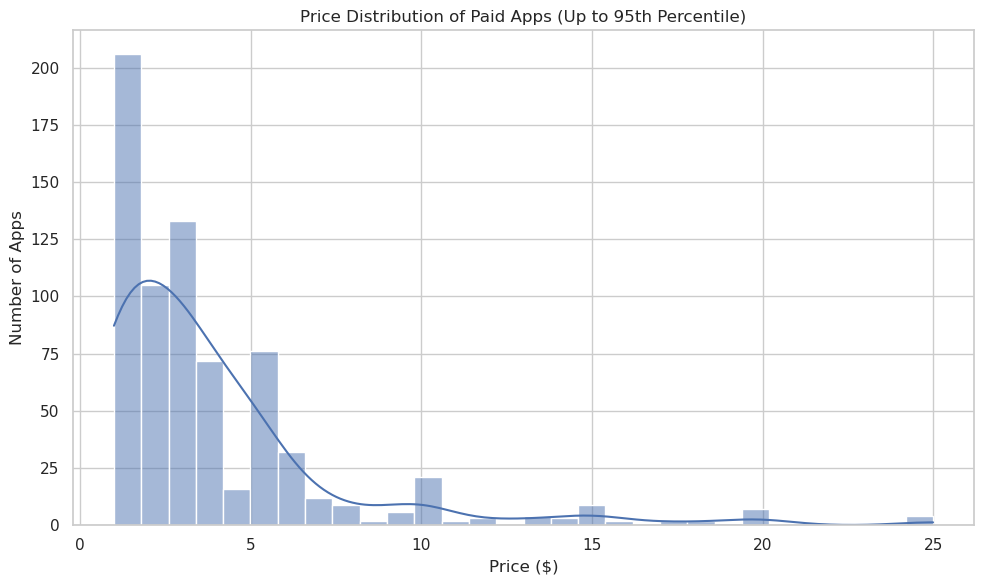

In [65]:
paid_apps = apps_df[
    (apps_df["Type"] == "Paid") &
    (apps_df["Price"] > 0)
].copy()

print("Number of paid apps:", len(paid_apps))
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()
price_filtered = paid_apps[
    paid_apps["Price"] <= paid_apps["Price"].quantile(0.95)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    price_filtered["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps (Up to 95th Percentile)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

Estimated Revenue by Category:
Category
FAMILY                 1.857803e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.786948e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6

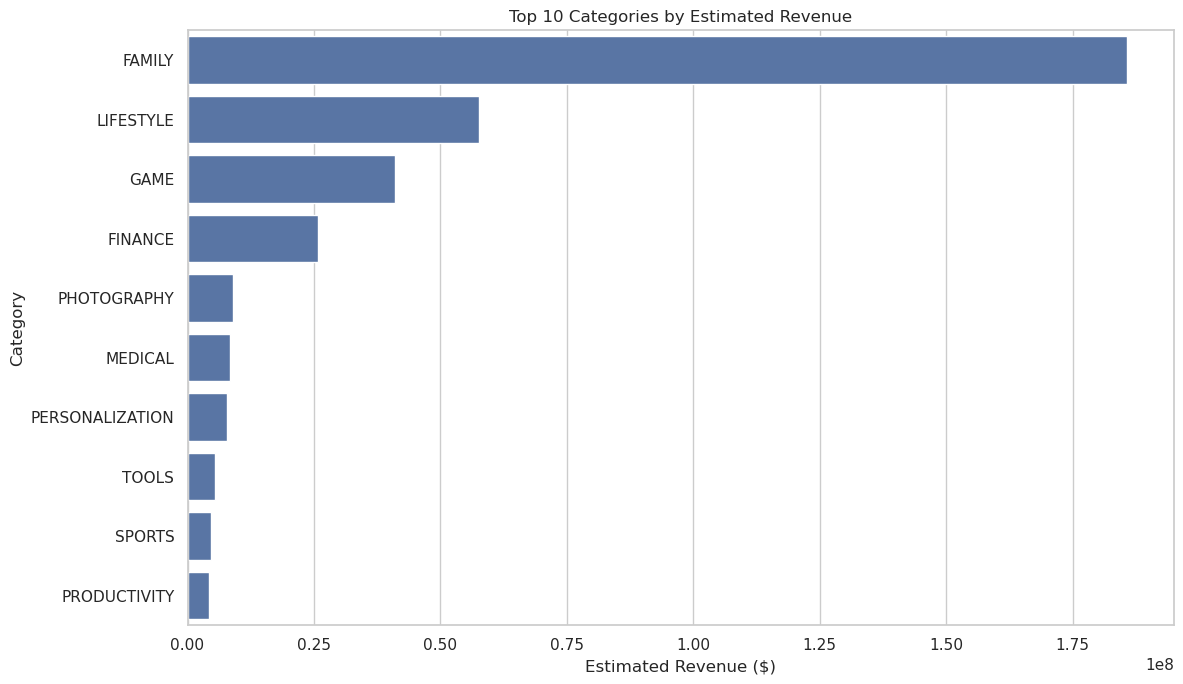

Highest estimated revenue category: FAMILY
Estimated revenue: $185,780,335.36


In [66]:
paid_apps["Estimated_Revenue"] = (
    paid_apps["Price"] *
    paid_apps["Installs"]
)

paid_apps[
    ["App", "Category", "Price", "Installs", "Estimated_Revenue"]
].head()

revenue_by_category = (
    paid_apps
    .groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
print(revenue_by_category)

top_revenue_categories = revenue_by_category.head(10)

print("Top 10 Categories by Estimated Revenue:")
print(top_revenue_categories)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_revenue_categories.values,
    y=top_revenue_categories.index
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

highest_revenue_category = revenue_by_category.idxmax()
highest_revenue = revenue_by_category.max()

print(
    f"Highest estimated revenue category: "
    f"{highest_revenue_category}"
)

print(
    f"Estimated revenue: ${highest_revenue:,.2f}"
)

#### Observation
The pricing analysis shows that free applications significantly outnumber paid applications on the Google Play Store, indicating that free apps are the dominant business model. Among paid applications, most apps are concentrated in the lower price range, while only a small number have very high prices. Estimated revenue varies across categories because it depends on both app price and number of installations. The category with the highest estimated revenue represents a potentially attractive market for paid applications, although the revenue calculation is only an estimate and does not account for platform fees, refunds, taxes, or actual purchases.

### Step 9: Sentiment analysis on user reviews: classify reviews as positive/negative/neutral using TextBlob or VADER

Sentiment Distribution:
Predicted_Sentiment
Positive    8636
Neutral     2068
Negative     137
Name: count, dtype: int64


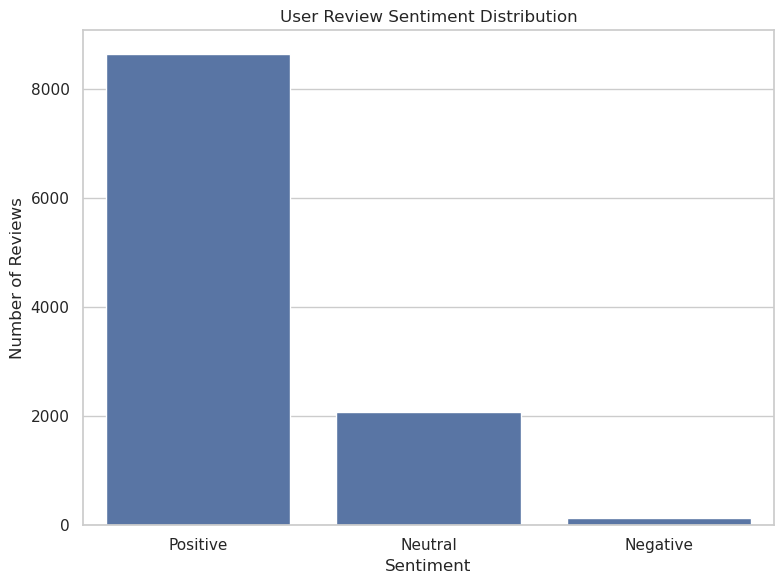

Sentiment Percentage:
Predicted_Sentiment
Positive    79.66
Neutral     19.08
Negative     1.26
Name: proportion, dtype: float64


In [82]:
from textblob import TextBlob
def classify_sentiment(review):
    polarity = TextBlob(str(review)).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

reviews_df["Predicted_Sentiment"] = reviews_df[
    "Translated_Review"
].apply(classify_sentiment)
reviews_df["Polarity"] = reviews_df[
    "Translated_Review"
].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
reviews_df[
    ["App", "Translated_Review", "Predicted_Sentiment", "Polarity"]
].head(10)
sentiment_counts = reviews_df[
    "Predicted_Sentiment"
].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)
plt.figure(figsize=(8, 6))

sns.countplot(
    data=reviews_df,
    x="Predicted_Sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()
sentiment_percentage = (
    reviews_df["Predicted_Sentiment"]
    .value_counts(normalize=True) * 100
)

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

#### Observation
TextBlob sentiment analysis classifies the user reviews into positive, negative, and neutral categories based on their polarity scores. The distribution helps identify the overall perception of users toward the applications. A higher proportion of positive reviews indicates greater user satisfaction, while negative reviews can highlight areas where developers may need to improve the application experience.

### Step 10: Sentiment by Category

Top 10 Categories with Most Positive Sentiment:
Category
1.9               100.00
EDUCATION          98.08
GAME               91.43
ART_AND_DESIGN     90.77
COMICS             90.00
PHOTOGRAPHY        88.96
SHOPPING           88.46
ENTERTAINMENT      87.25
WEATHER            86.59
SOCIAL             84.07
Name: Positive, dtype: float64


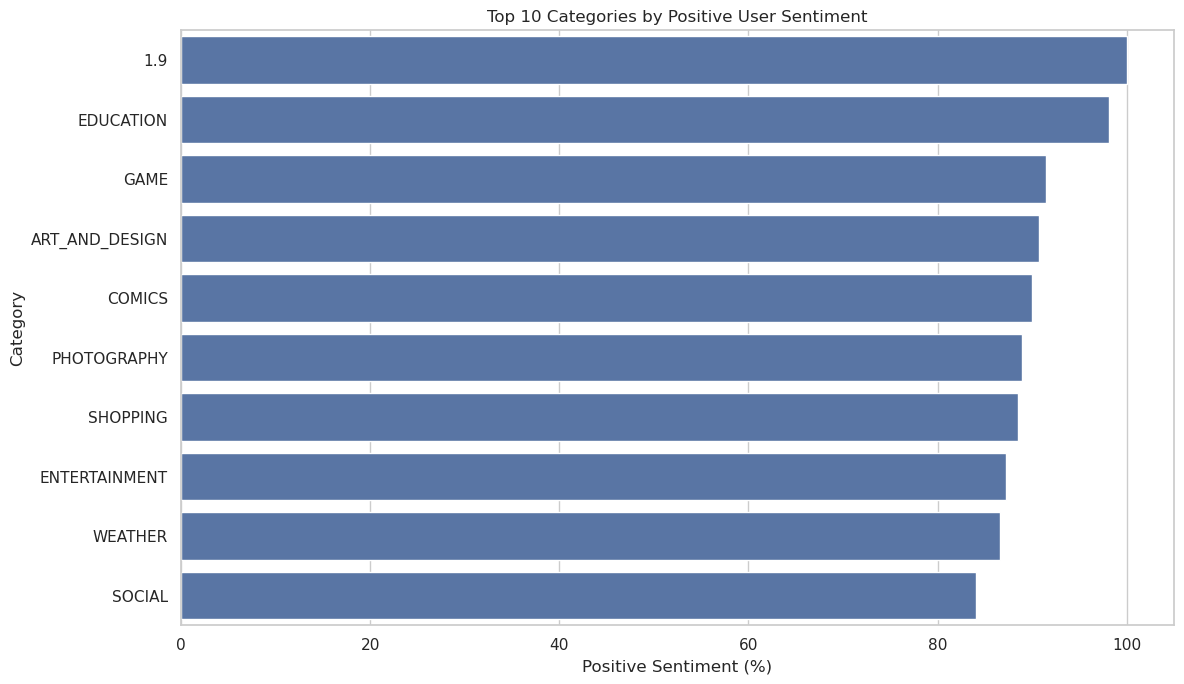

Top 10 Categories with Most Negative Sentiment:
Category
DATING                2.99
TOOLS                 2.97
HEALTH_AND_FITNESS    2.93
FINANCE               2.73
MEDICAL               2.59
NEWS_AND_MAGAZINES    2.47
BUSINESS              2.39
LIFESTYLE             2.36
AUTO_AND_VEHICLES     2.35
PHOTOGRAPHY           1.79
Name: Negative, dtype: float64


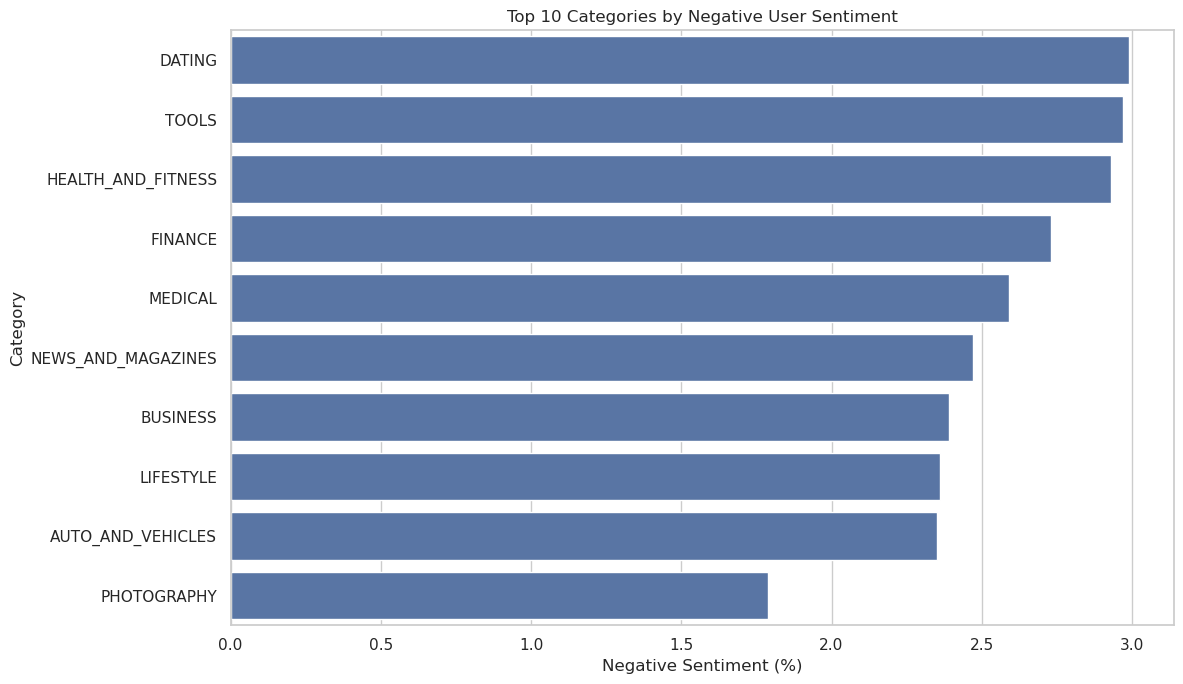

Category with highest positive sentiment: 1.9 (100.00%)
Category with highest negative sentiment: DATING (2.99%)


In [85]:
# Count Positive, Neutral and Negative reviews for each category
sentiment_by_category = pd.crosstab(
    reviews_df["Category"],
    reviews_df["Sentiment"]
)

sentiment_by_category
sentiment_percentage = pd.crosstab(
    reviews_df["Category"],
    reviews_df["Sentiment"],
    normalize="index"
) * 100

sentiment_percentage = sentiment_percentage.round(2)

sentiment_percentage
top_positive = (
    sentiment_percentage["Positive"]
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Categories with Most Positive Sentiment:")
print(top_positive)
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index
)

plt.title("Top 10 Categories by Positive User Sentiment")
plt.xlabel("Positive Sentiment (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()
top_negative = (
    sentiment_percentage["Negative"]
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Categories with Most Negative Sentiment:")
print(top_negative)
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index
)

plt.title("Top 10 Categories by Negative User Sentiment")
plt.xlabel("Negative Sentiment (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()
highest_positive_category = sentiment_percentage["Positive"].idxmax()
highest_positive_value = sentiment_percentage["Positive"].max()

highest_negative_category = sentiment_percentage["Negative"].idxmax()
highest_negative_value = sentiment_percentage["Negative"].max()

print(
    f"Category with highest positive sentiment: "
    f"{highest_positive_category} ({highest_positive_value:.2f}%)"
)

print(
    f"Category with highest negative sentiment: "
    f"{highest_negative_category} ({highest_negative_value:.2f}%)"
)

#### Observation
Sentiment analysis shows that user sentiment varies across app categories. Categories with a higher percentage of positive sentiment indicate stronger user satisfaction, while categories with a higher percentage of negative sentiment may have more opportunities for improvement. Comparing sentiment percentages rather than only review counts provides a fairer comparison between categories of different sizes.

### Step 11: At least one interactive visualisation using plotly (optional but strongly recommended)

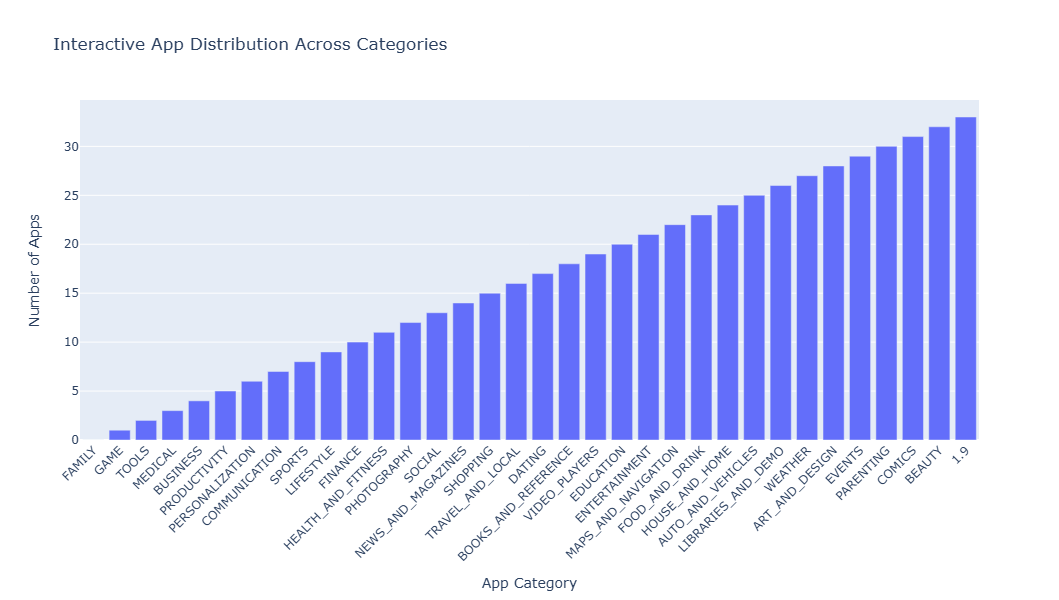

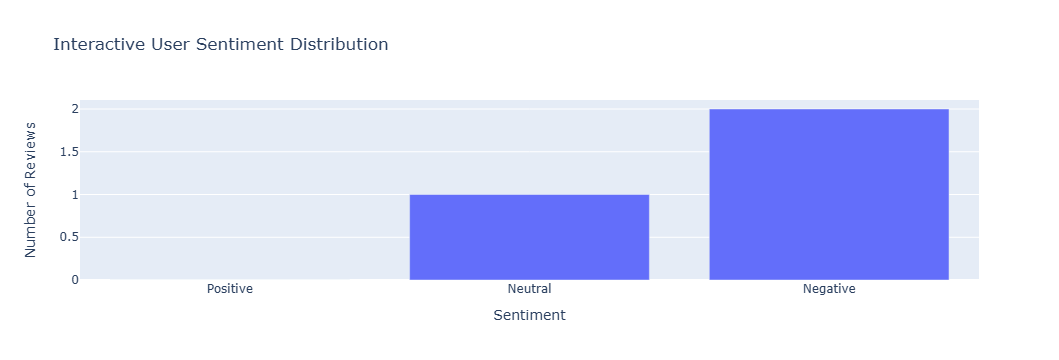

In [87]:
import plotly.express as px

# Count apps in each category
category_counts = (
    apps_df["Category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Number_of_Apps"]

# Create interactive bar chart
fig = px.bar(
    category_counts,
    x="Category",
    y="Number_of_Apps",
    title="Interactive App Distribution Across Categories",
    labels={
        "Category": "App Category",
        "Number_of_Apps": "Number of Apps"
    },
    hover_data=["Number_of_Apps"]
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

sentiment_counts = (
    reviews_df["Sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_counts.columns = ["Sentiment", "Number_of_Reviews"]

fig = px.bar(
    sentiment_counts,
    x="Sentiment",
    y="Number_of_Reviews",
    title="Interactive User Sentiment Distribution",
    labels={
        "Sentiment": "Sentiment",
        "Number_of_Reviews": "Number of Reviews"
    },
    text="Number_of_Reviews"
)

fig.update_traces(
    textposition="outside"
)

fig.show()

#### Observation
The interactive Plotly visualizations allow users to explore the data dynamically by hovering over the charts to view exact values. The category chart helps compare app concentration across different categories, while the sentiment chart provides an interactive comparison of positive, neutral, and negative user sentiment.

### Step 12: Conclusion: 3 data-driven insights for a developer planning to launch a new app

#### Conclusion 
- Choose the category carefully: The analysis shows that categories such as Family, Game, and Tools have a large number of apps, indicating strong competition. A developer should consider a less saturated category or offer a clear unique feature to differentiate the app.
- Focus on quality and user satisfaction: Most app ratings are concentrated around 4.0–4.5, showing that users generally expect high-quality applications. Developers should prioritize reliability, usability, performance, and user feedback to maintain a strong rating and positive sentiment.
- Prefer a user-friendly pricing strategy: Free apps dominate the Play Store, while paid apps represent a much smaller share. A developer could consider a freemium model—offering the basic app for free and monetizing through premium features or in-app purchases—while using user sentiment and engagement data to improve the product.

Final Conclusion
Overall, the analysis suggests that a successful new app should target an opportunity with manageable competition, provide a high-quality user experience, and adopt a pricing strategy aligned with user expectations. Data on category saturation, ratings, installations, pricing, and sentiment can help developers make more informed launch decisions.